## K562, GATA2 test set, bpnet architecture


## ENCSR000EVV

In [1]:
import h5py 

In [2]:
f=h5py.File("models/k562.gata2.seed.1234.cs.25.filters.64.idr.range.4.6.to.11.5.0.predictions",'r')

In [3]:
labels_0=f['lab_0'][:]
labels_1=f['lab_1'][:]
pred_0=f['pred_0'][:]
pred_1=f['pred_1'][:]
coord=f['coords'][:]

In [4]:
coord_fixed=[[i.decode('utf8')  for i in j] for j in coord]

In [5]:
coord_dict={} 
for i in range(len(coord_fixed)): 
    coord_dict[tuple(coord_fixed[i])]=i

In [6]:
import pandas as pd 
from scipy.stats import spearmanr 
from scipy.stats import pearsonr 
from scipy.special import softmax

## get ranked list of IDR peaks on chrom 1 (test chrom)

In [7]:
idr_peaks=pd.read_csv('test.set.0.sorted.bed',header=None,sep='\t')
idr_peaks['summit']=idr_peaks[1]+idr_peaks[9]
idr_peaks=idr_peaks.sort_values(by=[8],ascending=False)
positions=[]
top_peaks=20
count=0
for index,row in idr_peaks.iterrows(): 
    summit=row['summit']
    chrom=row[0]
    count+=1
    if count >top_peaks: 
        break
    positions.append((chrom,str(summit),'.'))
        

In [8]:
positions[0]

('chr1', '35506128', '.')

In [9]:
coord_dict[positions[0]]

386

In [10]:
## for plotting 
import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=10,5

In [11]:
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

In [12]:
pred_0_softmax=softmax(pred_0,axis=1)

In [13]:
pred_0_softmax.shape

(2773, 1000, 2)

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


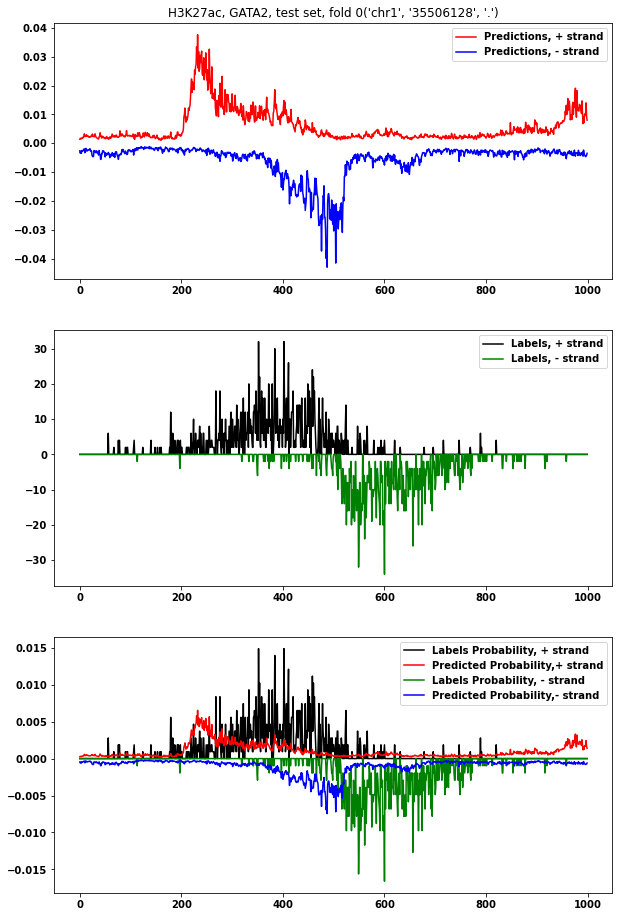

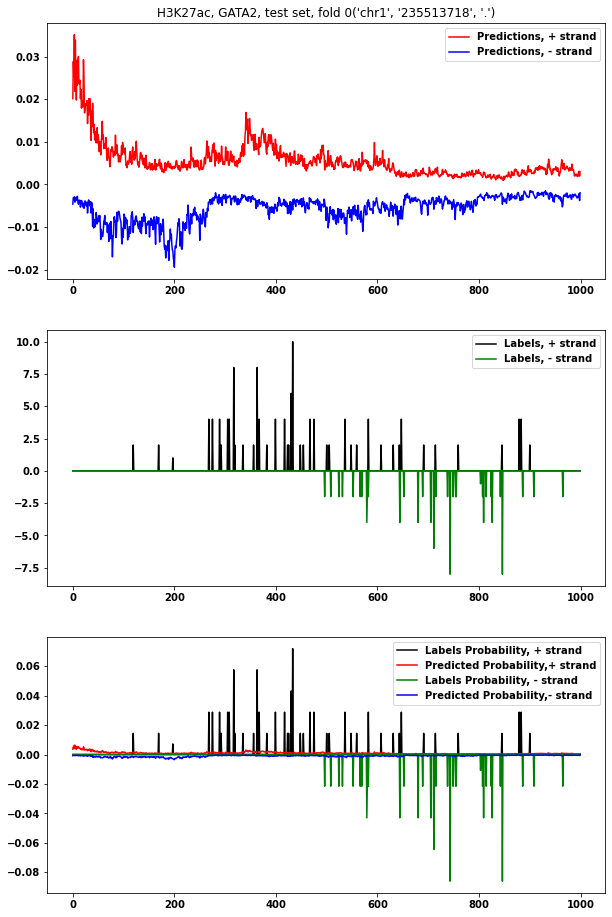

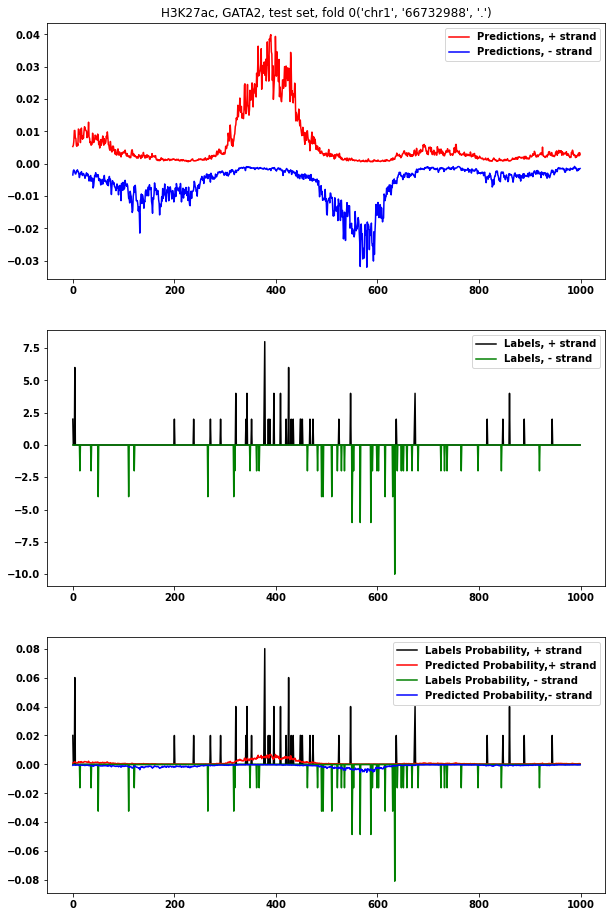

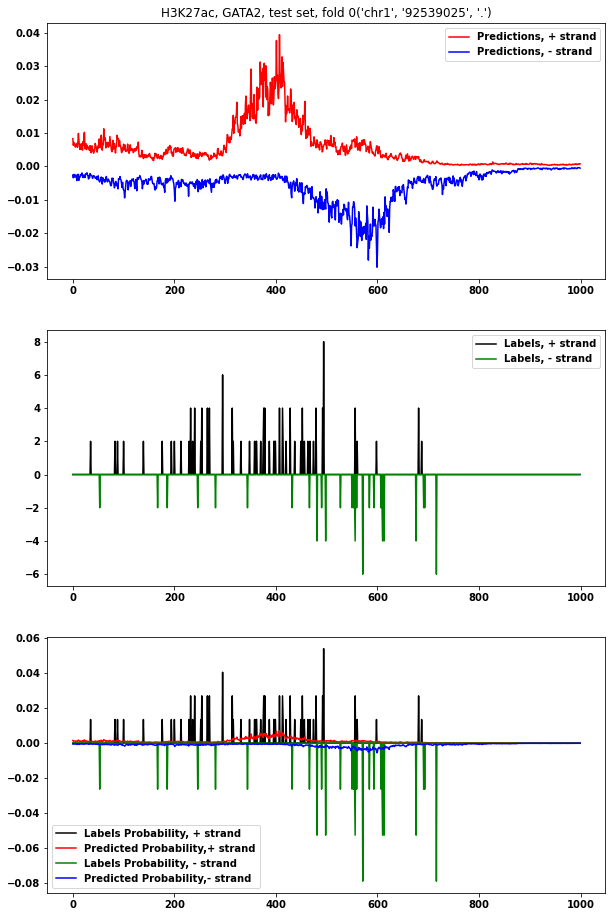

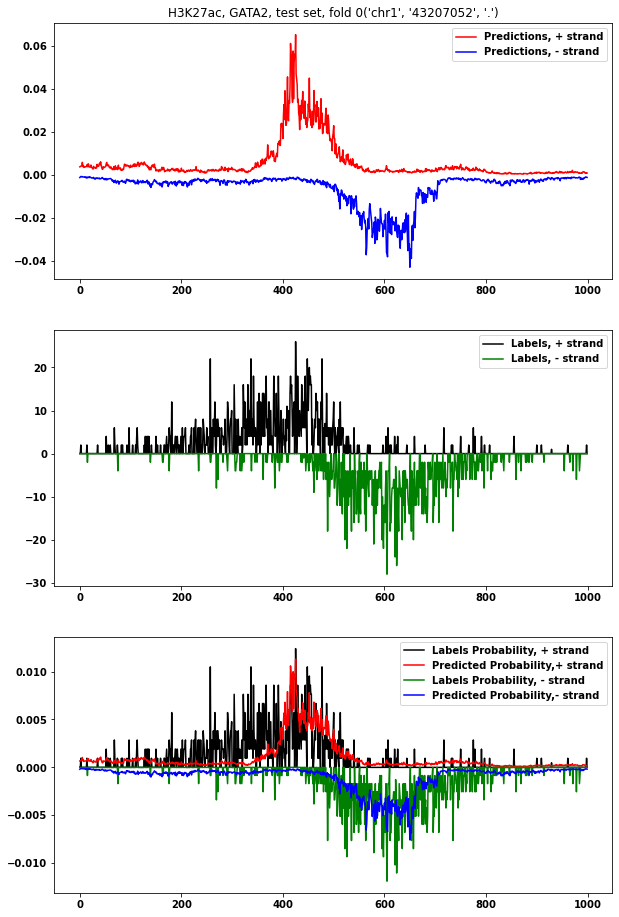

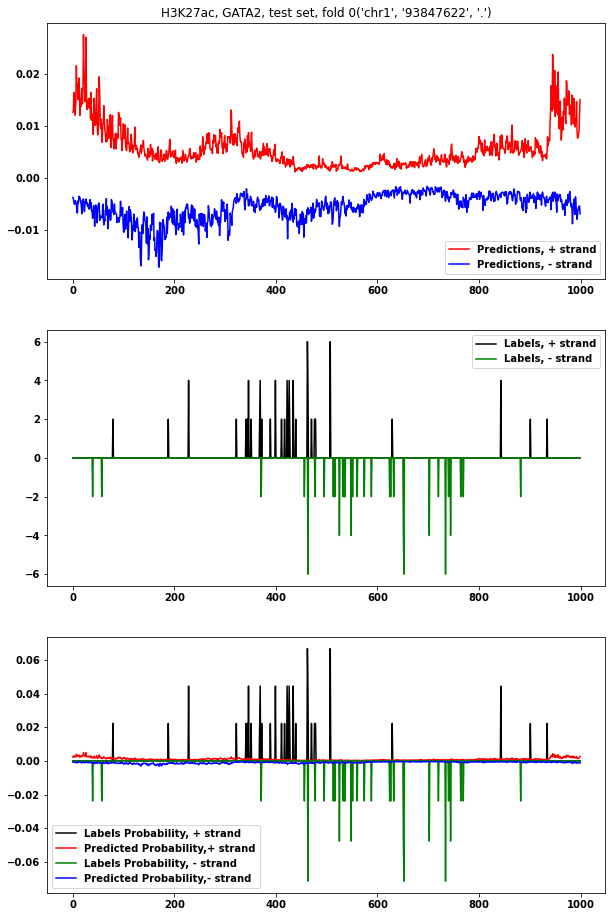

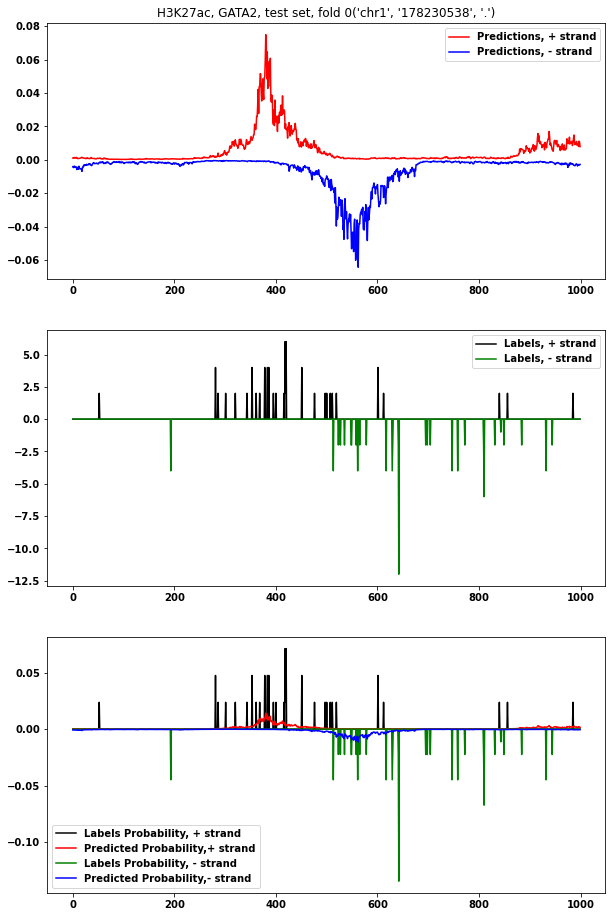

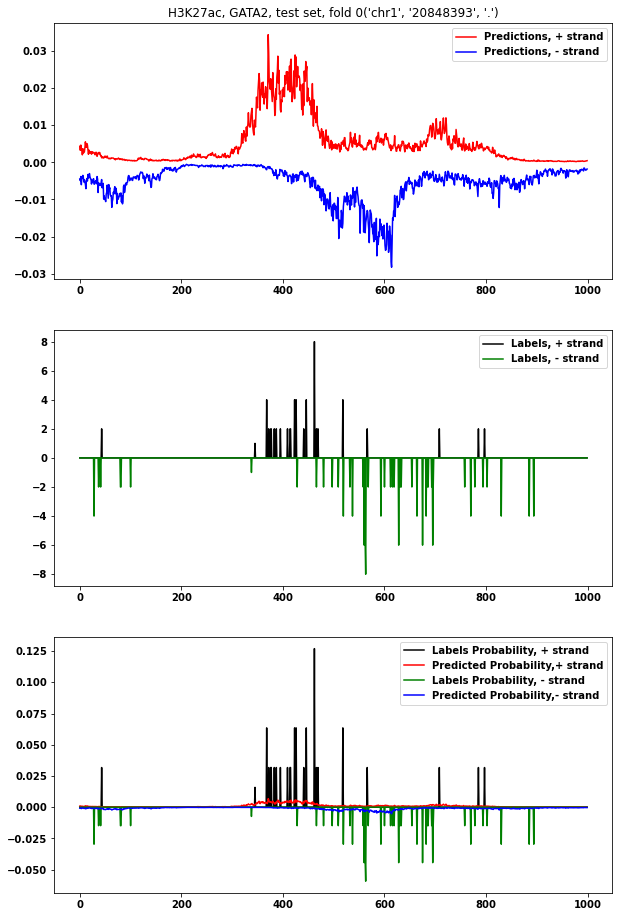

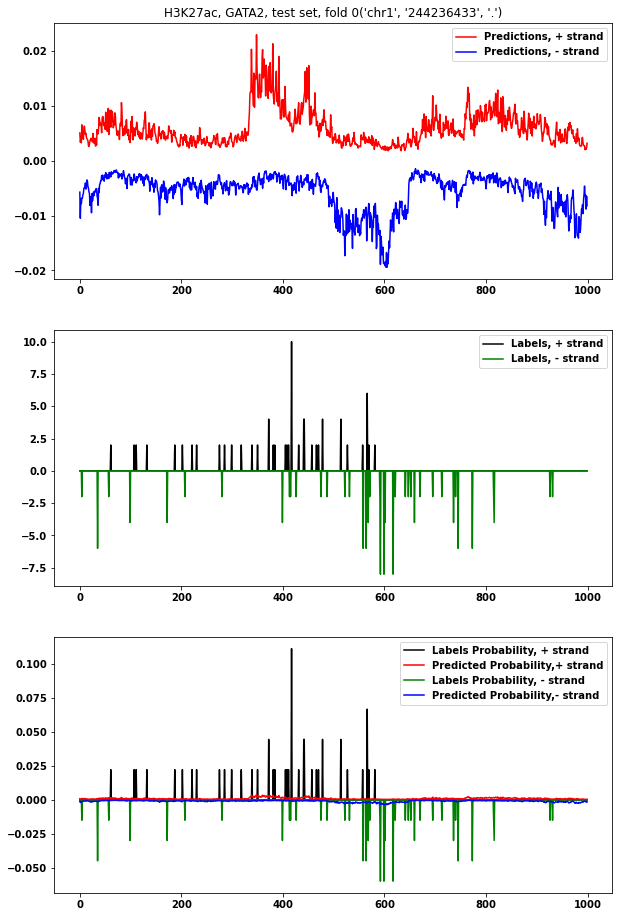

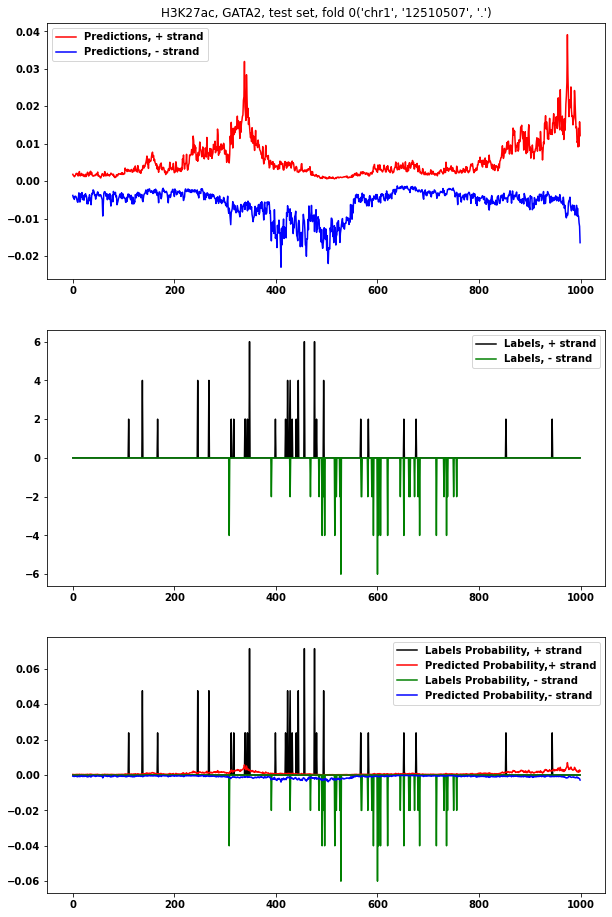

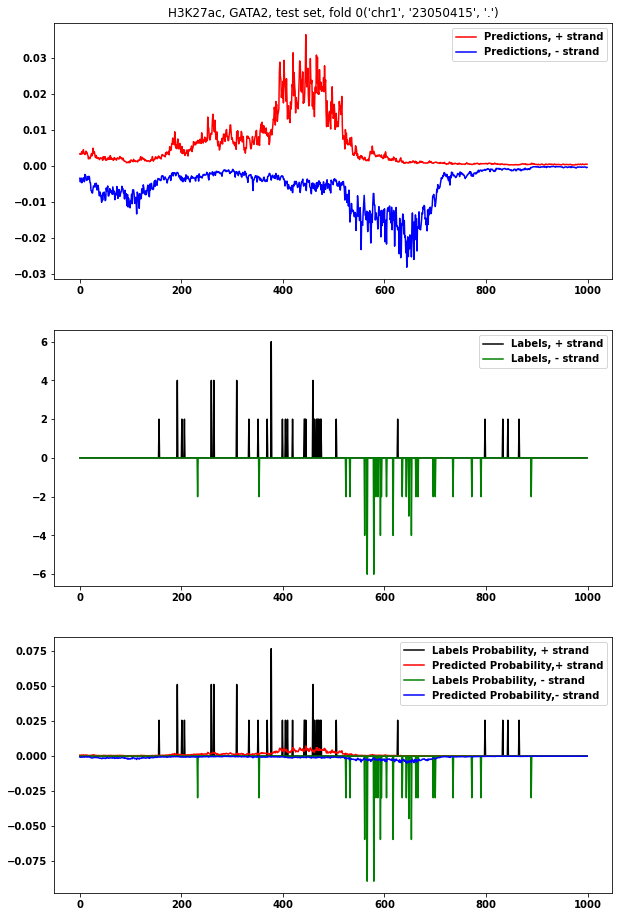

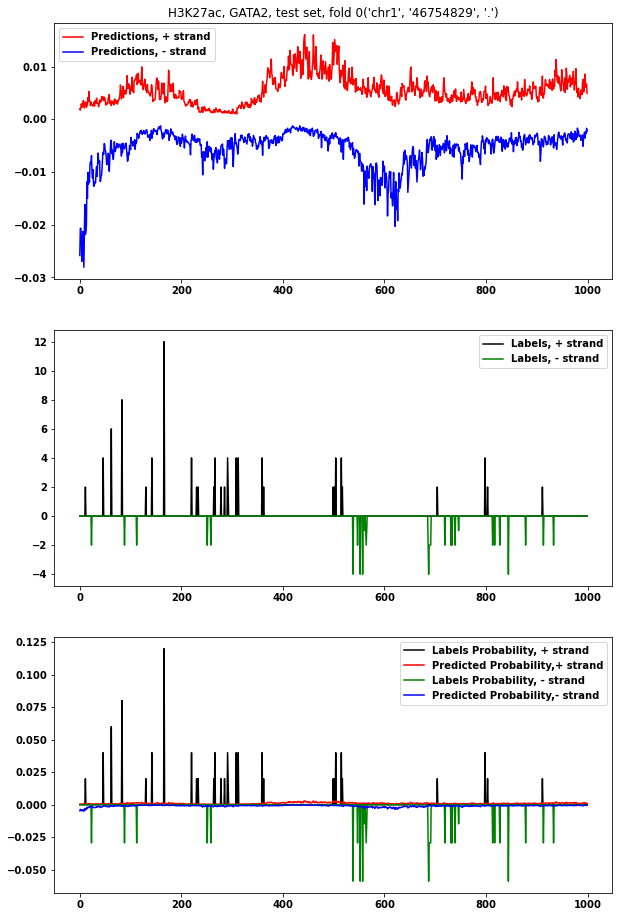

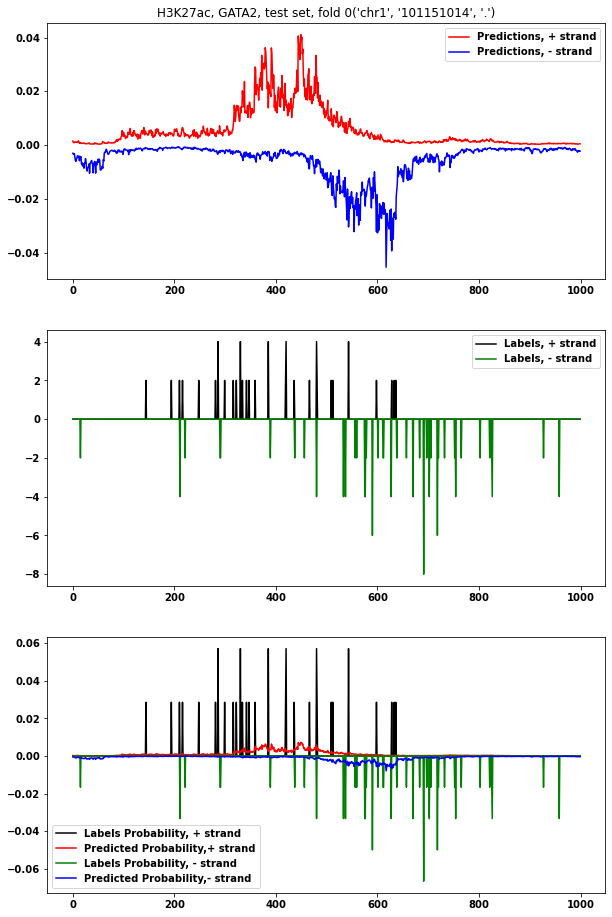

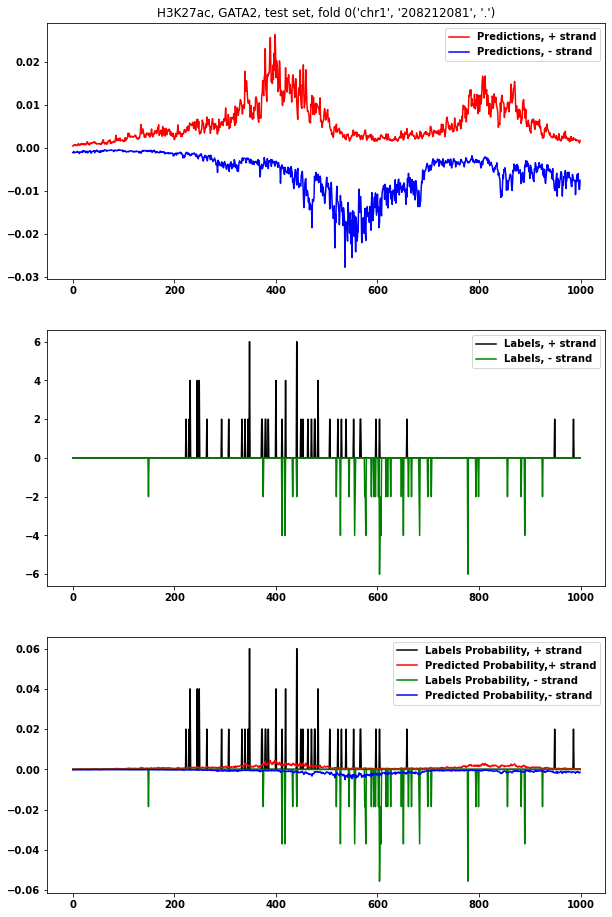

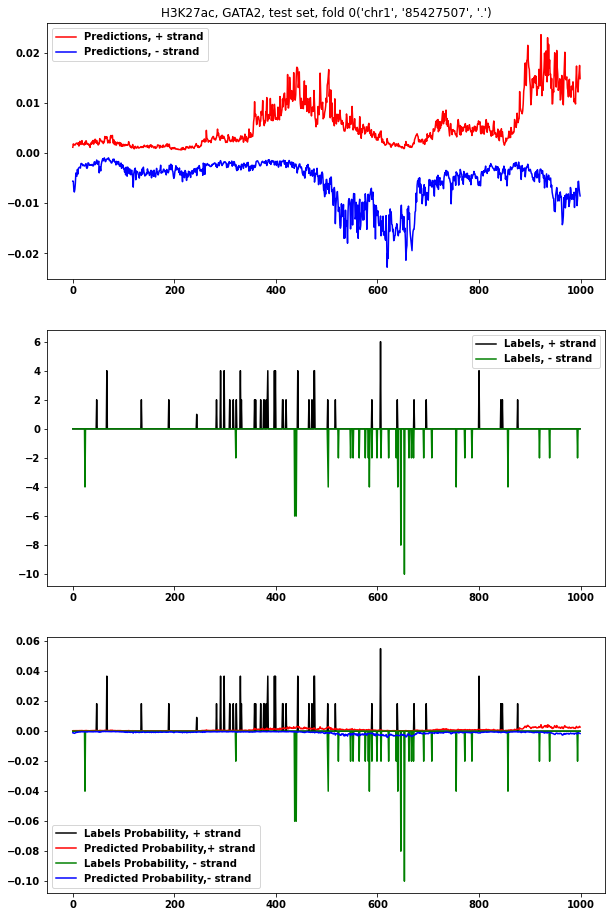

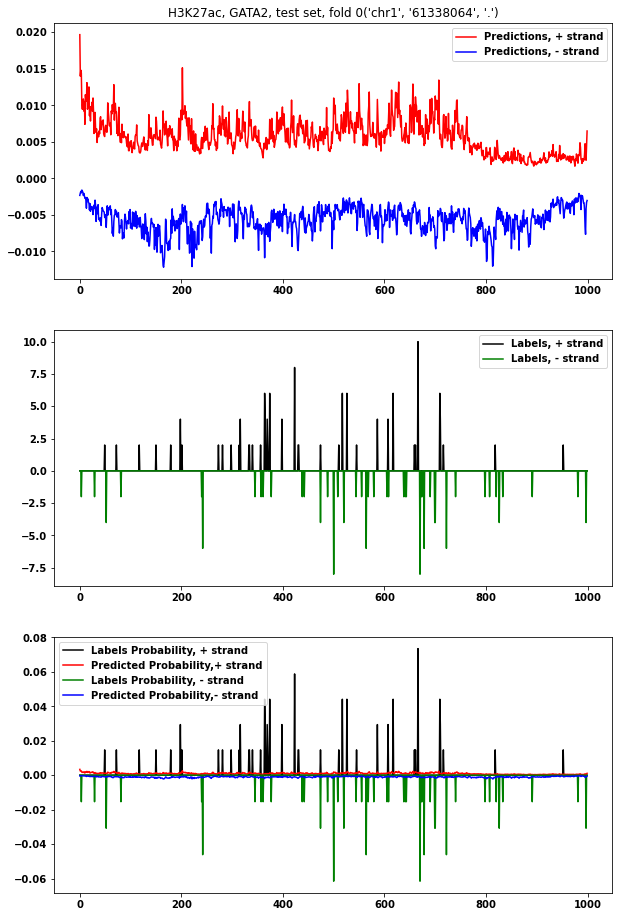

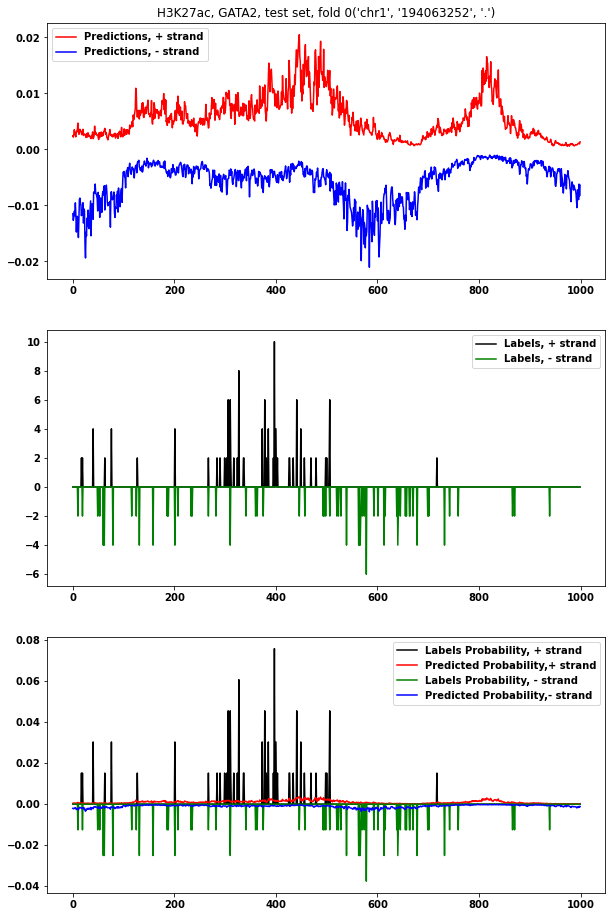

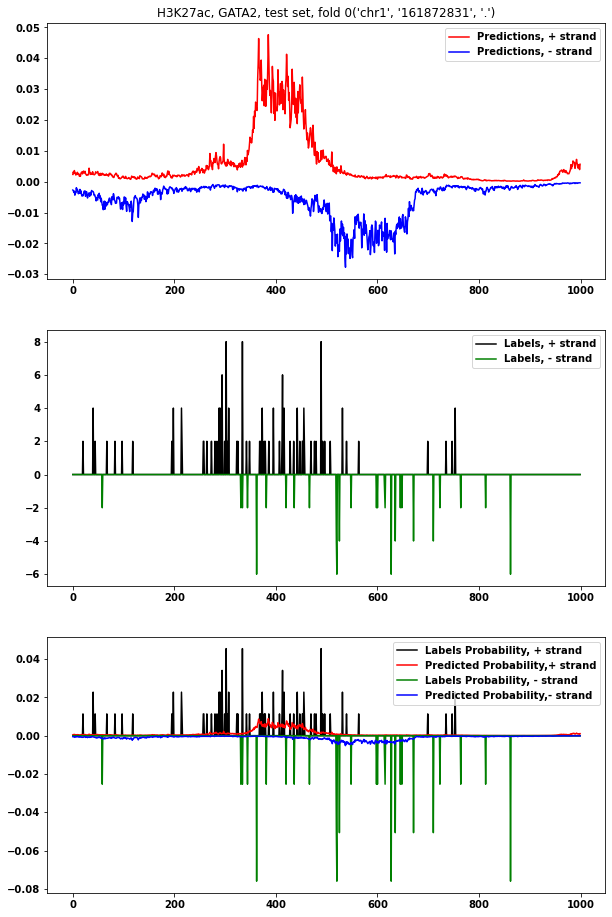

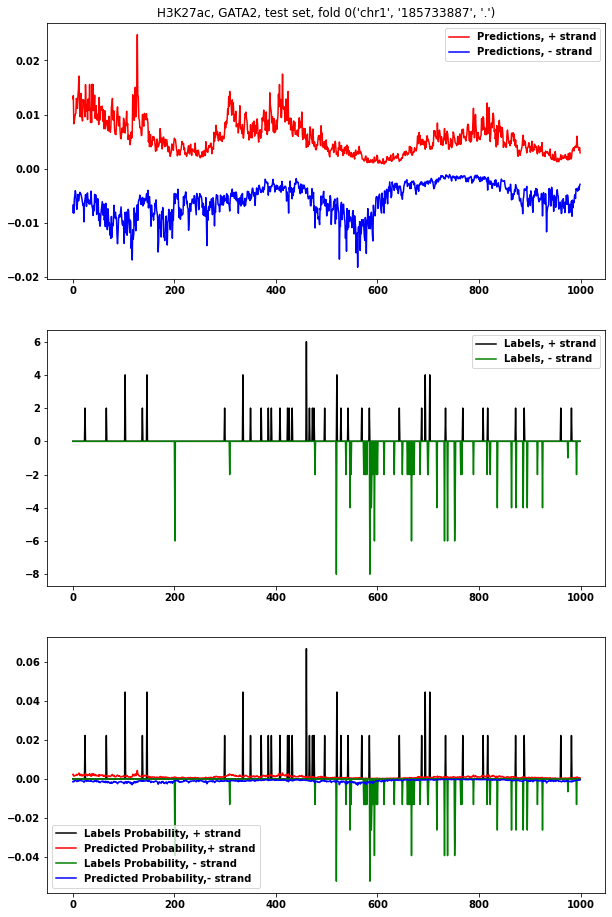

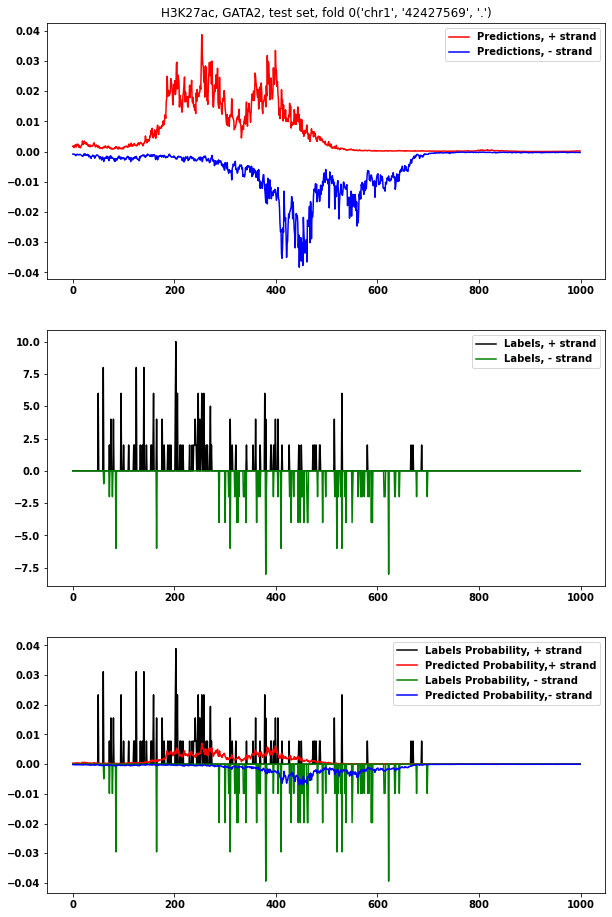

In [14]:
plt.rcParams["figure.figsize"]=10,16
title="H3K27ac, GATA2, test set, fold 0"
for pos in positions[0:20]: 
    cur_index=coord_dict[pos]
    counts_plus=pred_0_softmax[cur_index,:,0]*pred_1[cur_index,0]
    counts_minus=pred_0_softmax[cur_index,:,1]*pred_1[cur_index,1]
    prob_plus=pred_0_softmax[cur_index,:,0]
    prob_minus=pred_0_softmax[cur_index,:,1]
    fig, axes = plt.subplots(3, 1)
    probs_observed_forward=labels_0[cur_index,:,0]/sum(labels_0[cur_index,:,0])
    probs_observed_reverse=labels_0[cur_index,:,1]/sum(labels_0[cur_index,:,1])
    axes[0].plot(counts_plus,label='Predictions, + strand',color='r')
    axes[1].plot(labels_0[cur_index,:,0],label='Labels, + strand',color='k')
    axes[2].plot(probs_observed_forward,label="Labels Probability, + strand",color='k')
    axes[2].plot(pred_0_softmax[cur_index,:,0],label="Predicted Probability,+ strand",color='r')    
    axes[0].plot(-1*counts_minus,label='Predictions, - strand',color='b')
    axes[1].plot(-1*labels_0[cur_index,:,1],label='Labels, - strand',color='g')
    axes[2].plot(-1*probs_observed_reverse,label="Labels Probability, - strand",color='g')
    axes[2].plot(-1*pred_0_softmax[cur_index,:,1],label="Predicted Probability,- strand",color='b')            
    axes[0].set_title(title+str(pos))
    axes[0].legend()
    axes[1].legend() 
    axes[2].legend()
    plt.show() 
        


In [15]:
f.close()